In [ ]:
from uspas_llrf.llrf_app.app import LLRFApp
from uspas_llrf.utils import calc_ps, plot_ps
from pprint import pprint
import matplotlib.pyplot as plt
import time

plt.rcParams['figure.figsize'] = [6, 4]
plt.rcParams['axes.grid'] = True
plt.rcParams['axes.grid.which'] = "both"
plt.rcParams['grid.linewidth'] = 0.5
plt.rcParams['grid.alpha'] = 0.5
plt.rcParams['font.size'] = 8

%load_ext autoreload
%autoreload 2

# Program bitstream file
Connect 2586 MHz, 0dBm to zest clock input

In [ ]:
!make -C top/marble_zest/ system_config MARBLE_SERIAL=40 GIT_32BIT_ID=6fa0c193 FSET=LEMP

make: Entering directory '/home/du/work/uspas_llrf/llrf_fw/top/marble_zest'
Makefile:44: warning: overriding recipe for target '../../llrf_dsp/llrf_shell.json'
../../soc/marble_zest/common/llrf/rules.mk:12: warning: ignoring old recipe for target '../../llrf_dsp/llrf_shell.json'
Using Marble with serial number 40
openocd \
-c "adapter serial 000040;" \
-f marble.cfg \
-c "init; xc7_program xc7.tap; pld load 0 marble_zest_top_LEMP.6fa0c193.bit; exit"
Open On-Chip Debugger 0.12.0+dev-01158-g56d67dac2 (2025-08-25-18:54)
Licensed under GNU GPL v2
For bug reports, read
	http://openocd.org/doc/doxygen/bugs.html
Warn : DEPRECATED: auto-selecting transport "jtag". Use 'transport select jtag' to suppress this message.
fpga_program
Info : ftdi: if you experience problems at higher adapter clocks, try the command "ftdi tdo_sample_edge falling"
Info : clock speed 15000 kHz
Info : JTAG tap: xc7.tap tap/device found: 0x0364c093 (mfg: 0x049 (Xilinx), part: 0x364c, ver: 0x0)
Info : [xc7.proxy] Examina

# Read Board Support info

In [4]:
slac_b15_ip = '192.168.19.40:803'
llrf = LLRFApp(addr=slac_b15_ip, conf='LEMP',
               assert_system_bist=False,
               loopback_test=True,
               chan_keep=0b111)
llrf.get_bsp_info()

Marble Variant: V1.3
ADN4600 U2:
  IN 2 -> OUT 0
  IN 3 -> OUT 1
  IN 2 -> OUT 2
  IN 3 -> OUT 3
INA219 U57, 12V:
  Vshunt     :    -17.7 mV
  Power      :     50.0 mW
  Vbus       :     11.6 V
  Current    :   -943.1 mA
INA219 U17, FMC1:
  Vshunt     :    -31.4 mV
  Power      :     53.0 mW
  Vbus       :     11.6 V
  Current    :    202.3 mA
INA219 U32, FMC2:
  Vshunt     :    -21.3 mV
  Power      :     46.9 mW
  Vbus       :     11.6 V
  Current    :    134.6 mA
 PCA9555 U34, QSFP:
  I0         :    01111111
  I1         :    01111111
 PCA9555 U39, MISC:
  I0         :    11111110
  I1         :    11110011
SI570:
  regs       :    b'\xE0\xC2\xDD\x0B\x33\x77'
  HSDIV      :    11
  N1         :    4
  f_reset    :     125.000 MHz
  f_xtal_hz  :     114.285 MHz
  f_out_hz   :     119.000 MHz
Zest Clocks:
  Freq  ADC0_DIV :  119.001 MHz
  Freq  ADC1_DIV :  119.001 MHz
  Freq  DAC_DCO  :  238.001 MHz
  Freq  DSP_CLK  :  119.001 MHz
  Phase ADC0_DIV :    0.356 UI
  Phase ADC1_DIV :    

In [5]:
pprint(llrf.model.cal_factors)

LLRFCalibrations(rx_gain=np.float64(3.1140127017135355),
                 tx_gain=np.float64(1.548405151243776),
                 rx_phase_off_deg=np.float64(79.45922771026024),
                 tx_phase_off_deg=np.float64(64.28571428571426),
                 rx_dds_omega_deg=np.float64(77.14285714285714),
                 tx_dds_omega_deg=np.float64(38.57142857142857),
                 cic_wfm_gain=np.complex128(11.58233428572094-6.800116025829079e-16j),
                 inlk_gain=np.complex128(0.596041493687356-3.4994252568580604e-17j),
                 inlk_tx_gain=np.complex128(-2.1998110175157648e-17-0.3352218065205768j),
                 rx_iq_gain=np.complex128(1.8909933527707667-1.1102230246251564e-16j),
                 tx_iq_gain=np.complex128(-6.17031507025233e-17+0.9402735726757961j),
                 max_adc_input=31129.6,
                 max_dac_drive=31129.6,
                 max_amp_setpoint=np.float64(20104.298913623967))


## Measure a snapshot of RF amplitude and phases

In [25]:
llrf.init_open_loop_demo(2e4)

In [26]:
df_mon = llrf.get_rfmon()
df_mon

,mon_amp,mon_phs,Amp [cnt],Phs [deg]
adc0,6644,15609,11146.874958,4.287140e+01
adc1,2,-49138,3.355471,-1.349615e+02
adc2,2,-49138,3.355471,-1.349615e+02
adc3,2,-65226,3.355471,-1.791486e+02
adc4,2,-32458,3.355471,-8.914856e+01
adc5,0,-32458,0.000000,0.000000e+00
adc6,2,-49138,3.355471,-1.349615e+02
adc7,2,-65226,3.355471,-1.791486e+02
dac0,6706,-32768,20004.665179,3.126015e-13
dac1,6706,-32768,20004.665179,3.126015e-13


Confirm MO phase is aligned

In [9]:
mo_adc_chan = llrf.read_reg('prl_adc_chan')
fdbk_adc_chan = llrf.read_reg('fdbk_adc_chan')
mo_adc = f'adc{mo_adc_chan}'
fdbk_adc = f'adc{fdbk_adc_chan}'
print(f'MO ADC = {mo_adc}, FDBK ADC = {fdbk_adc}')

MO ADC = adc3, FDBK ADC = adc0


In [214]:
assert -0.2 < df_mon['Phs [deg]'][mo_adc] < 0.2

## Plot raw DAC / ADC data

In [13]:
df_sig = llrf.get_raw_bufs_df()

<Axes: xlabel='Time [ns]'>

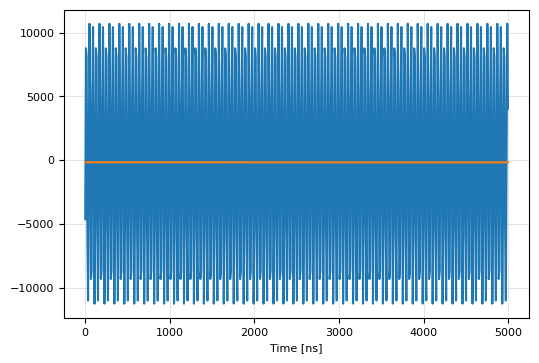

In [14]:
df_sig[fdbk_adc].loc[:5000].plot()
df_sig[mo_adc].loc[:5000].plot()

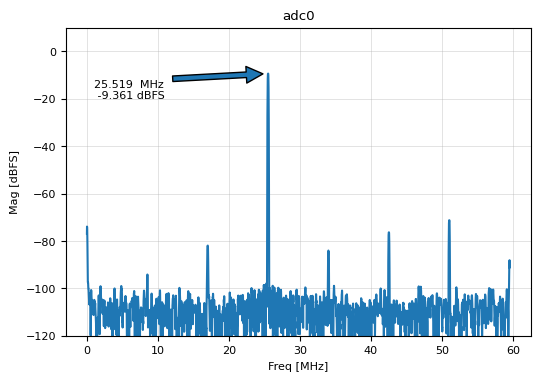

In [16]:
f, psd_dbfs = calc_ps(df_sig[fdbk_adc], fs_mhz=1e3/llrf.model.DSP_CLK_CYCLE)
plot_ps(f, psd_dbfs, title=fdbk_adc, annotate=True)

# Pulse mode test

In [27]:
# generate 4µs pulse
pulse_high_len = int(4000 / llrf.model.DSP_CLK_CYCLE)
llrf.reg_write([
    # ('amp_setpoint', 12000),
    ('pulse_high_len', pulse_high_len),
    ('pulse_mode', 1)
])
time.sleep(0.5)

print(f'pulse_high_len: {pulse_high_len} counts')

pulse_high_len: 476 counts


<Axes: xlabel='Time [ns]'>

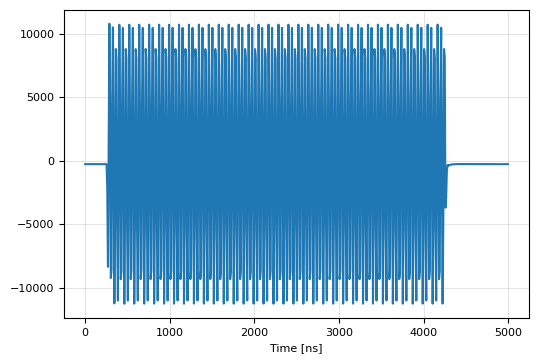

In [19]:
df_sig = llrf.get_raw_bufs_df()
df_sig['adc0'].loc[:5000].plot()

In [20]:
df_iq = llrf.get_iq_wfms_df()

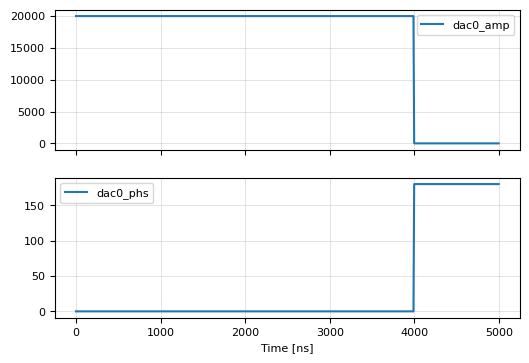

In [21]:
len_ns = 5000
fig, axes = plt.subplots(2, sharex=True)
df_iq[['dac0' + '_amp']].loc[:len_ns].plot(ax=axes[0])
df_iq[['dac0' + '_phs']].loc[:len_ns].plot(ax=axes[1]);

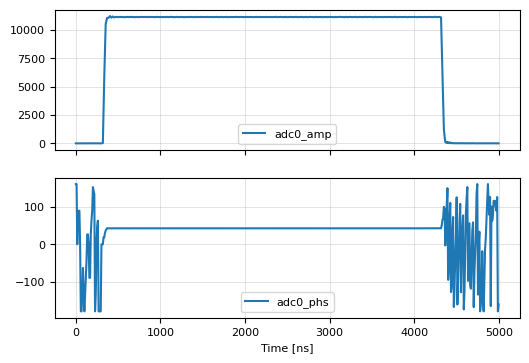

In [22]:
fig, axes = plt.subplots(2, sharex=True)
df_iq[[fdbk_adc + '_amp']].loc[:len_ns].plot(ax=axes[0])
df_iq[[fdbk_adc + '_phs']].loc[:len_ns].plot(ax=axes[1]);

Verify IQ waveform signal gain:

In [28]:

amp = df_iq[[fdbk_adc + '_amp']].loc[500:4000].values.mean()
phs = df_iq[[fdbk_adc + '_phs']].loc[500:4000].values.mean()
print(f'fdbk_adc IQ waveform signal: amp = {amp:8.3f} cnt, phs = {phs:8.3f} deg')

amp_exp = df_mon['Amp [cnt]'][fdbk_adc]
phs_exp = df_mon['Phs [deg]'][fdbk_adc]
print(f'fdbk_adc expected inlk_mon:  amp = {amp_exp:8.3f} cnt, '
      f'phs = {phs_exp:8.3f} deg')

fdbk_adc IQ waveform signal: amp = 11150.823 cnt, phs =   42.866 deg
fdbk_adc expected inlk_mon:  amp = 11146.875 cnt, phs =   42.871 deg


## Plot circular buffer data

In [29]:
df_mp = llrf.get_cic_wfm_df()

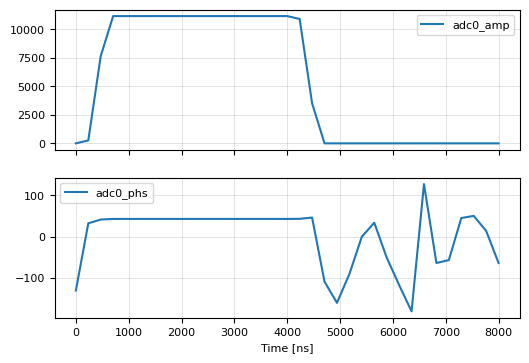

In [30]:
len_ns = 8000
fig, axes = plt.subplots(2, sharex=True)
df_mp[fdbk_adc + '_amp'].loc[:len_ns].plot(ax=axes[0], legend=True)
df_mp[fdbk_adc + '_phs'].loc[:len_ns].plot(ax=axes[1], legend=True);